### BIG DATA LAB3: Machine Learning on Spark
Thực hiện cây quyết định dự đoán trên tập dữ liệu NYC Taxi Trip Duration với RDD (low-level)

Họ và tên: Phan Bá Đức

MSSV: 22120071

___

In [29]:
from pyspark.sql import SparkSession
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

spark = SparkSession.builder \
    .appName("LowLevelDecisionTreeNYCTaxi") \
    .master("local[*]") \
    .getOrCreate()

sc = spark.sparkContext
print(f"Spark master: {sc.master}")

Spark master: local[*]


25/05/10 00:10:06 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [2]:
train_lines = sc.textFile("hdfs://localhost:9000/hcmus/nyc-taxi-trip-duration/train.csv")
test_lines = sc.textFile("hdfs://localhost:9000/hcmus/nyc-taxi-trip-duration/test.csv")

header_train = train_lines.first()
train_data = train_lines.filter(lambda line: line != header_train)
header_test = test_lines.first()
test_data = test_lines.filter(lambda line: line != header_test)

feature_cols = ["pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude"]
train_numeric_indices = [5, 6, 7, 8]  # pickup_longitude, pickup_latitude, dropoff_longitude, dropoff_latitude
target_index = 10  # trip_duration

def parse_train_line(line):
    try:
        values = line.split(",")
        features = [float(values[i]) for i in train_numeric_indices]
        target = float(values[target_index])
        if any(v is None for v in features + [target]):
            return None
        return (features, target)
    except:
        return None

train_rdd = train_data.map(parse_train_line).filter(lambda x: x is not None).cache()

---

### Tìm hiểu dữ liệu (EDA)

In [3]:
count = train_rdd.count()
print(f"Số dòng dữ liệu: {count}")

stats_rdd = train_rdd.map(lambda row: row[0] + [row[1]]) # Chuyển [[feature1, feature2, ...], target] thành [feature1, feature2, ..., target]

# Tính tổng cho từng cột
sums = stats_rdd.reduce(lambda a, b: [x + y for x, y in zip(a, b)])

# Tính trung bình cho từng cột
means = [s / count for s in sums]

# Tính min và max cho từng cột
# mins = stats_rdd.map(lambda row: tuple(row)).reduce(lambda a, b: tuple(min(x, y) for x, y in zip(a, b)))
# maxs = stats_rdd.map(lambda row: tuple(row)).reduce(lambda a, b: tuple(max(x, y) for x, y in zip(a, b)))
mins = stats_rdd.reduce(lambda a, b: [min(x, y) for x, y in zip(a, b)])
maxs = stats_rdd.reduce(lambda a, b: [max(x, y) for x, y in zip(a, b)])

# Tính quartile (Q1, Q2, Q3) bằng cách sắp xếp
def get_quantiles(rdd, index, count, quantiles=[0.25, 0.5, 0.75]):
    """
    Tính các phân vị (quantiles) cho một cột cụ thể trong RDD
    
    Args:
        rdd: RDD chứa dữ liệu [features, target]
        index: Chỉ số của cột cần tính toán
        count: Tổng số lượng mẫu (để tiết kiệm bộ nhớ thì thay vì tính count ở đây, ta có thể truyền biến có sẵn vào từ bên ngoài)
        quantiles: Danh sách các phân vị cần tính (mặc định [0.25, 0.5, 0.75])
        
    Returns:
        list: Giá trị của các phân vị tương ứng
    """
    # Sắp xếp RDD theo cột được chọn và đánh chỉ mục
    # Ví dụ: [[1, 5, 3], [4, 10, 6], [7, 8, 9]] -(với index = 1)-> [5, 10, 8] -(sort)->[5, 8, 10] -(zipWithIndex)-> [(5, 0), (8, 1), (10, 2)]
    sorted_rdd = rdd.map(lambda x: x[index]).sortBy(lambda x: x).zipWithIndex() 
    # Tính vị trí của các phân vị
    positions = [int(q * count) for q in quantiles]
    return [v[0] for v in sorted_rdd.filter(lambda x: x[1] in positions).collect()] # Lấy giá trị tại các vị trí phân vị

quantile_results = []
for i in range(len(feature_cols) + 1): # thêm 1 để tính cho trip_duration
    quantiles = get_quantiles(stats_rdd, i, count)
    quantile_results.append(quantiles)

# Tạo DataFrame để hiển thị thống kê mô tả
stats_df = pd.DataFrame({
    "Count": [count] * (len(feature_cols) + 1),
    "Mean": means,
    "Min": mins,
    "Max": maxs,
    "Q1 (25%)": [q[0] for q in quantile_results],
    "Q2 (50%)": [q[1] for q in quantile_results],
    "Q3 (75%)": [q[2] for q in quantile_results]
}, index=feature_cols + ["trip_duration"])  # Đặt tên các cột
print(stats_df)

# Kiểm tra missing data và duplicate
missing_data = train_rdd.filter(lambda x: any(v is None for v in x[0] + [x[1]])).count()
print(f"Số dòng dữ liệu bị thiếu: {missing_data}")

# Kiểm tra dữ liệu trùng lặp
# Chuyển các list thành tuple (vì list không hashable được)
train_rdd_tuples = train_rdd.map(lambda x: (tuple(x[0]), x[1]))

# Lấy các dòng duy nhất (distinct)
rdd_distinct = train_rdd_tuples.distinct()

# Tính số lượng bản ghi trùng lặp
duplicate_count = train_rdd_tuples.count() - rdd_distinct.count()
print(f"Số dòng trùng lặp: {duplicate_count}")

print(f"Số dòng sau khi xóa trùng: {rdd_distinct.count()}")

Số dòng dữ liệu: 1458644


                     Count        Mean         Min           Max    Q1 (25%)  \
pickup_longitude   1458644  -73.973486 -121.933342 -6.133553e+01  -73.991867   
pickup_latitude    1458644   40.750921   34.359695  5.188108e+01   40.737347   
dropoff_longitude  1458644  -73.973416 -121.933304 -6.133553e+01  -73.991325   
dropoff_latitude   1458644   40.751800   32.181141  4.392103e+01   40.735886   
trip_duration      1458644  959.492273    1.000000  3.526282e+06  397.000000   

                     Q2 (50%)     Q3 (75%)  
pickup_longitude   -73.981743   -73.967331  
pickup_latitude     40.754101    40.768360  
dropoff_longitude  -73.979752   -73.963013  
dropoff_latitude    40.754524    40.769810  
trip_duration      662.000000  1075.000000  


Số dòng dữ liệu bị thiếu: 0


Số dòng trùng lặp: 9


Số dòng sau khi xóa trùng: 1458635


In [4]:
# 3. Phân chia tập train và validation
train_split, val_split = rdd_distinct.randomSplit([0.8, 0.2], seed=22120071)

# Cache dữ liệu để tăng hiệu suất (tránh tính toán lại nhiều lần)
train_split = train_split.cache()
val_split = val_split.cache()

print(f"\nSố dòng tập train: {train_split.count()}")
print(f"Số dòng tập validation: {val_split.count()}")


Số dòng tập train: 1167963


Số dòng tập validation: 290672


---

### Xây dựng Decision Tree Regressor (low-level)

##### **Công thức phương sai mẫu**
$$
\text{variance} = \frac{1}{N - 1} \sum_{i=1}^N (x_i - \mu)^2
$$
Suy ra
$$
\text{variance} = \frac{1}{N - 1} \left(\sum_{i=1}^N x_i^2 - N\mu^2 \right)
$$
Nếu là phương sai tổng thể thì chia cho `N`

##### **Các bước của thuật toán**

Bước 1: Khởi tạo
- Bắt đầu với node gốc chứa toàn bộ dữ liệu $ D $.
- Đặt các tham số:
  - $ \text{max\_depth} $: Độ sâu tối đa của cây (ví dụ: 3).
  - $ \text{min\_samples\_split} $: Số mẫu tối thiểu để tiếp tục phân chia (ví dụ: 10).

Bước 2: Kiểm tra điều kiện dừng
Tại mỗi node, kiểm tra:
- Nếu số mẫu $ n < \text{min\_samples\_split} $, hoặc độ sâu đạt $ \text{max\_depth} $, hoặc không còn đặc trưng nào để chia:
  - Tạo node lá với giá trị dự đoán là trung bình $ \bar{y} $.
- Nếu không, tiếp tục tìm điểm phân chia.

Bước 3: Tìm điểm phân chia tối ưu
- Với mỗi đặc trưng $ j $ (ví dụ: `pickup_longitude`, `pickup_latitude`, ...):
  - Chọn tập hợp các ngưỡng $ t $ (thresholds):
    - Trong code, lấy 10 ngưỡng dựa trên phân vị (quantiles) để giảm thời gian tính toán (nếu còn ít hơn 10 mẫu thì lấy tất cả làm ngưỡng):

  - Với mỗi ngưỡng $ t $:
    - Chia dữ liệu thành $ D_{\text{left}} $ và $ D_{\text{right}} $.
    - Tính phương sai:
      $$
      \text{Var}(D_{\text{left}}), \text{Var}(D_{\text{right}})
      $$
    - Tính weighted variance:
      $$
      \text{Weighted Variance} = \frac{n_{\text{left}}}{n} \cdot \text{Var}(D_{\text{left}}) + \frac{n_{\text{right}}}{n} \cdot \text{Var}(D_{\text{right}})
      $$
    - Tính Variance Reduction:
      $$
      \text{Gain} = \text{Var}(D) - \text{Weighted Variance}
      $$
- Chọn $ j, t $ có Gain lớn nhất ($ \text{best\_feature}, \text{best\_threshold} $).
- Nếu $ \text{Gain} \leq 0 $, dừng và tạo node lá.

Bước 4: Phân chia đệ quy
- Sử dụng $ \text{best\_feature} $ và $ \text{best\_threshold} $ để chia $ D $ thành $ D_{\text{left}} $ và $ D_{\text{right}} $.
- Đệ quy gọi hàm xây dựng cây cho $ D_{\text{left}} $ (nhánh trái) và $ D_{\text{right}} $ (nhánh phải), tăng độ sâu lên 1.

Bước 5: Dự đoán
- Với một mẫu mới $ x $:
  - Bắt đầu từ node gốc, duyệt cây theo các điều kiện phân chia ($ x_j \leq t $).
  - Khi đến node lá, trả về giá trị $ \hat{y} $ (trung bình của node lá).

In [5]:

def compute_variance(data_rdd, isSample=True):
    '''
    Tính phương sai của nhãn (target) trong RDD
    Args:
        data_rdd: RDD chứa dữ liệu [[features], target]
        isSample: True nếu là mẫu (sample), False nếu là tổng thể (population)
    Returns:
        tuple: (phương sai, số lượng mẫu) # trả về số lượng mẫu để bên ngoài sử dụng hàm không mất thời gian tính lại
    '''
    count = data_rdd.count()

    if count == 0:
        return 0.0, 0
    
    sum_y, sum_y_squared = data_rdd.map(lambda x: (x[1], x[1] ** 2)).reduce(lambda a, b: (a[0] + b[0], a[1] + b[1]))
    mean_y = sum_y / count

    variance = 0
    if isSample:
        variance = (sum_y_squared - count * mean_y ** 2) / (count - 1)
    else:
        variance = (sum_y_squared - count * mean_y ** 2) / count
    return variance, count

def find_best_split(data_rdd, feature_indices):
    '''
    Tìm cách chia tốt nhất cho một node trong cây quyết định
    
    Args:
        data_rdd: RDD chứa dữ liệu
        feature_indices: Danh sách chỉ số các feature cần xem xét
        
    Returns:
        tuple: (best_feature, best_threshold, best_gain (AKA variance reduction))
    '''
    best_gain = 0.0
    best_feature = None
    best_threshold = None
    # Tính phương sai tổng thể của node hiện tại
    total_variance, total_count = compute_variance(data_rdd)
    
    # Duyệt qua từng feature để tìm cách chia tốt nhất
    for feature_idx in feature_indices:
        # Lấy 10 ngưỡng chia dựa trên phân vị (percentile) (nếu số lượng mẫu bé hơn 10 thì lấy tất cả)
        number_of_thresholds = min(11, total_count + 1)
        values = data_rdd.map(lambda x: x[0][feature_idx]).sortBy(lambda x: x).zipWithIndex()
        positions = [int(i * total_count / number_of_thresholds) for i in range(1, number_of_thresholds)]  # number_of_thresholds ngưỡng
        thresholds = [v[0] for v in values.filter(lambda x: x[1] in positions).collect()]
        
        for threshold in thresholds:
            # Chia dữ liệu thành 2 nhánh theo ngưỡng
            # cache lại RDD sau khi chia để tránh tính toán lại nhiều lần
            left_rdd = data_rdd.filter(lambda x: x[0][feature_idx] <= threshold).cache()
            right_rdd = data_rdd.filter(lambda x: x[0][feature_idx] > threshold).cache()
            
            # Tính phương sai cho từng nhánh
            left_variance, left_count = compute_variance(left_rdd)
            right_variance, right_count = compute_variance(right_rdd)
            
            # Giải phóng bộ nhớ
            left_rdd.unpersist()
            right_rdd.unpersist()
            
            # Bỏ qua nếu một nhánh rỗng
            if left_count == 0 or right_count == 0:
                continue
            
            # Tính phương sai trung bình có trọng số
            weighted_variance = (left_count * left_variance + right_count * right_variance) / total_count

            # Tính độ giảm phương sai (variance reduction)
            gain = total_variance - weighted_variance
            
            # Cập nhật cách chia tốt nhất
            if gain > best_gain:
                best_gain = gain
                best_feature = feature_idx
                best_threshold = threshold
    
    return best_feature, best_threshold, best_gain

class Node:
    def __init__(self, feature_idx=None, threshold=None, left=None, right=None, value=None):
        self.feature_idx = feature_idx
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value  # Giá trị dự đoán (mean của nhãn)

def build_tree(data_rdd, feature_indices, max_depth, min_samples_split=10, depth=0):
    """
    Xây dựng cây quyết định đệ quy
    
    Args:
        data_rdd: Dữ liệu huấn luyện
        feature_indices: Danh sách các feature
        max_depth: Độ sâu tối đa của cây
        min_samples_split: Số mẫu tối thiểu để tiếp tục chia
        depth: Độ sâu hiện tại
        
    Returns:
        Node: Node gốc của cây
    """
    variance, count = compute_variance(data_rdd)
    # Điều kiện dừng: đạt độ sâu tối đa hoặc số mẫu ít hơn quy quy định
    if count < min_samples_split or depth >= max_depth:
        if count == 0:
            return Node(value=0.0)
        mean_value = data_rdd.map(lambda x: x[1]).reduce(lambda a, b: a + b) / count
        return Node(value=mean_value)
    
    # Tìm cách chia tốt nhất
    best_feature, best_threshold, best_gain = find_best_split(data_rdd, feature_indices)
    
    # Nếu không tìm được cách chia tốt hơn thì đó là node lá
    if best_feature is None or best_gain <= 0:
        mean_value = data_rdd.map(lambda x: x[1]).reduce(lambda a, b: a + b) / count
        return Node(value=mean_value)
    
    # Chia dữ liệu thành 2 nhánh theo ngưỡng tốt nhất
    left_rdd = data_rdd.filter(lambda x: x[0][best_feature] <= best_threshold)
    right_rdd = data_rdd.filter(lambda x: x[0][best_feature] > best_threshold)
    
    # Xây dựng cây đệ quy
    left_node = build_tree(left_rdd, feature_indices, max_depth, min_samples_split, depth + 1)
    right_node = build_tree(right_rdd, feature_indices, max_depth, min_samples_split, depth + 1)
    
    return Node(feature_idx=best_feature, threshold=best_threshold, left=left_node, right=right_node)

In [6]:
# Huấn luyện cây
feature_indices = list(range(len(feature_cols)))
tree = build_tree(train_split, feature_indices, max_depth=5, min_samples_split=10)

In [19]:
# Hàm dự đoán cho một điểm dữ liệu
def predict_tree(node, features):
    """
    Dự đoán giá trị cho một điểm dữ liệu bằng cách duyệt cây quyết định
    
    Args:
        node: Node hiện tại đang xét (thường là root)
        features: giá trị các đặc trưng của điểm dữ liệu cần dự đoán
        
    Returns:
        float: Giá trị dự đoán
    """
    # Nếu là node lá (có giá trị dự đoán)
    if node.value is not None:
        return node.value
    
    # Nếu không, tiếp tục đi xuống nhánh trái hoặc phải
    if features[node.feature_idx] <= node.threshold:
        return predict_tree(node.left, features)
    else:
        return predict_tree(node.right, features)

##### Dự đoán trên tập validation

In [ ]:
# val_split có dạng [(features, target), ...]
# val_predictions có dạng [(target, predicted_value), ...]
val_predictions = val_split.map(lambda x: (x[1], predict_tree(tree, x[0])))

In ra một vài mẫu so sánh giữa kết quả dự đoán và kết quả thực tế trên tập Validation

In [18]:
for target, predicted_value  in val_predictions.take(5):
    print(f"Target: {target}, Predicted: {predicted_value}")

Target: 1414.0, Predicted: 753.3961339466949
Target: 707.0, Predicted: 788.3887543082226
Target: 526.0, Predicted: 1137.6423483455883
Target: 721.0, Predicted: 753.3961339466949
Target: 1003.0, Predicted: 1562.9956129561297


25/05/09 23:27:01 WARN BlockManager: Task 11706 already completed, not releasing lock for rdd_60_0


In [16]:
# Đánh giá mô hình
def compute_metrics(predictions_rdd):
    """
    Tính các chỉ số đánh giá hiệu suất mô hình
    
    Args:
        predictions_rdd: RDD chứa các cặp (y_true, y_pred)
        
    Returns:
        tuple: (RMSE, MAE, R²)
    """
    count = predictions_rdd.count()
    if count == 0:
        return 0.0, 0.0, 0.0
    
    # RMSE
    squared_errors = predictions_rdd.map(lambda x: (x[0] - x[1]) ** 2)
    rmse = np.sqrt(squared_errors.reduce(lambda a, b: a + b) / count)
    
    # MAE
    abs_errors = predictions_rdd.map(lambda x: abs(x[0] - x[1]))
    mae = abs_errors.reduce(lambda a, b: a + b) / count
    
    # R²
    mean_y = predictions_rdd.map(lambda x: x[0]).reduce(lambda a, b: a + b) / count
    ss_tot = predictions_rdd.map(lambda x: (x[0] - mean_y) ** 2).reduce(lambda a, b: a + b)
    ss_res = squared_errors.reduce(lambda a, b: a + b)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
    
    return rmse, mae, r2

rmse, mae, r2 = compute_metrics(val_predictions)
print("\n=== Đánh giá mô hình trên tập validation ===")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")


=== Đánh giá mô hình trên tập validation ===
RMSE: 2975.75
MAE: 488.79
R²: 0.02


Vẽ biểu đồ so sánh giá trị thực tế và giá trị dự đoán

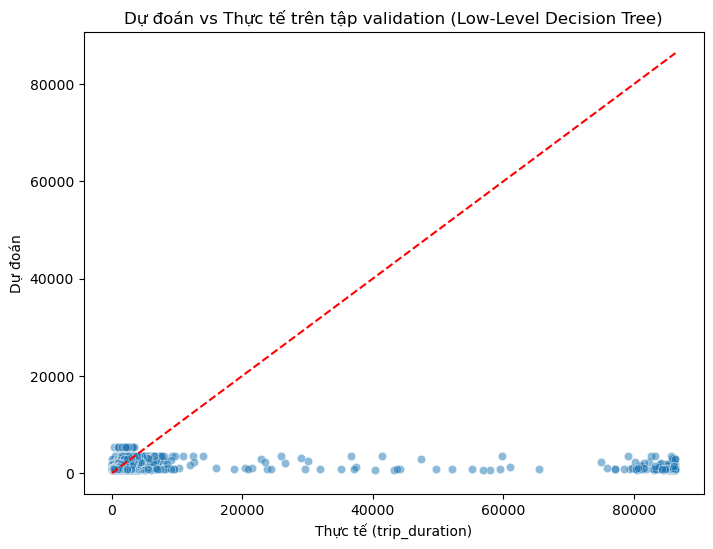

In [8]:
# Chuyển đổi RDD validation predictions sang Pandas DataFrame để vẽ biểu đồ
val_predictions_pd = pd.DataFrame(
    val_predictions.collect(),          # Chuyển RDD thành list
    columns=["Actual", "Predicted"]
    )
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="Actual", y="Predicted", 
    data=val_predictions_pd, 
    alpha=0.5
    )
plt.plot([0, val_predictions_pd["Actual"].max()], [0, val_predictions_pd["Actual"].max()], 'r--')
plt.xlabel("Thực tế (trip_duration)")
plt.ylabel("Dự đoán")
plt.title("Dự đoán vs Thực tế trên tập validation (Low-Level Decision Tree)")
plt.show()

##### Trực quan hóa hình ảnh cây quyết định huấn luyện trên tập train

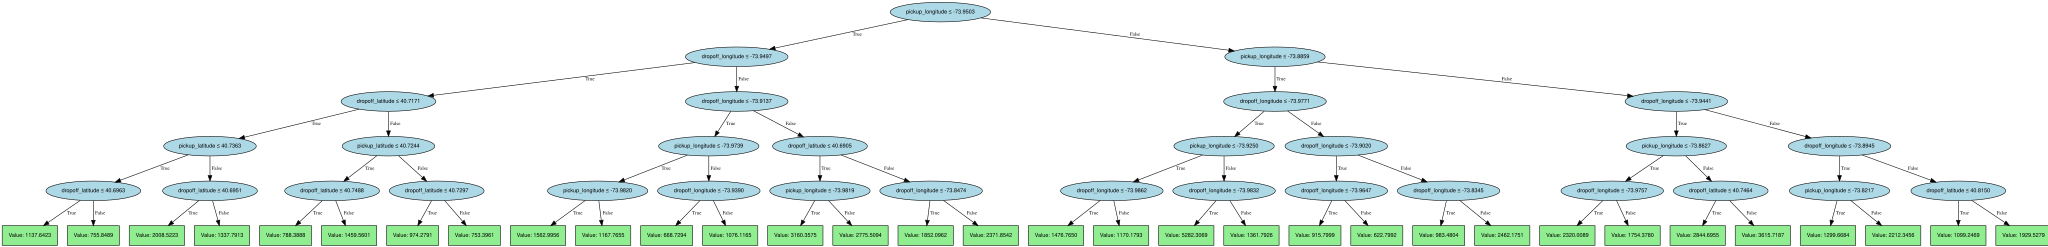

In [27]:
from graphviz import Digraph
from IPython.display import display, SVG

def visualize_decision_tree(tree, feature_names, class_names=None, max_depth=None):
    """
    Trực quan hóa cây quyết định sử dụng Graphviz
    
    Parameters:
    - tree: Node gốc của cây quyết định
    - feature_names: Danh sách tên các đặc trưng
    - class_names: Danh sách tên các lớp (cho bài toán phân loại)
    - max_depth: Độ sâu tối đa cần hiển thị (None để hiển thị toàn bộ cây)
    
    Returns:
    - Hiển thị SVG của cây trong notebook
    - Có thể bỏ comment dòng return dot để export ra file
    """
    # Khởi tạo đồ họa Graphviz
    dot = Digraph(comment='Decision Tree', format='svg')
    # Thiết lập thuộc tính đồ họa
    dot.attr('graph', 
             rankdir='TB',  # Hướng cây từ trên xuống (Top to Bottom)
             size='40,40')  # Kích thước đồ họa
    
    dot.attr('node', fontname='Helvetica', fontsize='10')
    
    # Biến đếm để tạo ID duy nhất cho các node
    node_counter = [0]
    
    def add_node(node, parent_id=None, edge_label=None, current_depth=0):
        """
        Hàm đệ quy thêm các node vào đồ họa
        
        Args:
            node: Node hiện tại
            parent_id: ID node cha
            edge_label: Nhãn cạnh nối
            current_depth: Độ sâu hiện tại
        """
        # Kiểm tra nếu vượt quá max_depth
        if max_depth is not None and current_depth > max_depth:
            return
        
        # Tạo ID duy nhất cho node
        node_id = f'node_{node_counter[0]}'
        node_counter[0] += 1
        
        # Xây dựng nhãn cho node
        if node.value is not None:  # Node lá
            if class_names: 
                # Cho bài toán phân loại
                class_label = class_names[int(node.value)] if isinstance(node.value, (int, float)) else str(node.value)
                label = f'Class: {class_label}'
            else:
                # Cho bài toán hồi quy
                label = f'Value: {node.value:.4f}'
            
            # Tạo node lá với style màu xanh lá
            dot.node(node_id, label, 
                    shape='box', 
                    style='filled', 
                    fillcolor='lightgreen',
                    fontsize='10')
            
        else:  # Node quyết định
            feature_name = feature_names[node.feature_idx]
            label = f'{feature_name} ≤ {node.threshold:.4f}'
            dot.node(node_id, label,
                    shape='ellipse',
                    style='filled',
                    fillcolor='lightblue',
                    fontsize='10')
        
        # Kết nối với node cha nếu có
        if parent_id is not None:
            dot.edge(parent_id, node_id, label=edge_label, fontsize='9')
        
        # Thêm các node con đệ quy
        if hasattr(node, 'left') and node.left is not None:
            add_node(node.left, node_id, 'True', current_depth + 1)
        if hasattr(node, 'right') and node.right is not None:
            add_node(node.right, node_id, 'False', current_depth + 1)
    
    # Bắt đầu xây dựng cây từ node gốc
    add_node(tree)
    
    display(SVG(dot.pipe(format='svg')))
    
    # Return dot object for further customization or export
    # return dot
visualize_decision_tree(tree, feature_cols, max_depth=5)

##### Kiểm tra trên tập test

In [14]:
# Tạo riêng chỉ số cột features cho tập test vì khác với tập train
test_numeric_indices = [4, 5, 6, 7]  # pickup_longitude, pickup_latitude, dropoff_longitude, dropoff_latitude
def parse_test_line_with_id(line):
    try:
        values = line.split(",")
        id_val = values[0]  # Cột id
        features = [float(values[i]) for i in test_numeric_indices]
        if any(v is None for v in features):
            return None
        return (id_val, features)
    except:
        return None


# Parse test data để giữ id
test_rdd = test_data.map(parse_test_line_with_id).filter(lambda x: x is not None).cache()

# Dự đoán
predictions = test_rdd.map(lambda x: (x[0], predict_tree(tree, x[1])))

data_lines = predictions.map(lambda x: f"{x[0]},{x[1]}")

# Chèn header vào partition đầu tiên
def insert_header(index, iterator):
    if index == 0:
        yield "id,trip_duration"
    yield from iterator

final_rdd = data_lines.mapPartitionsWithIndex(insert_header)

output_path = "hdfs://localhost:9000/hcmus/nyc-taxi-trip-duration/predictions"
final_rdd.saveAsTextFile(output_path)

print(f"Dự đoán đã được lưu vào {output_path}")

Dự đoán đã được lưu vào hdfs://localhost:9000/hcmus/nyc-taxi-trip-duration/predictions


In ra một vài mẫu

In [ ]:
for id, value in predictions.take(10):
    print(f"ID: {id}, Dự đoán: {value:.2f}")

ID: id3004672, Dự đoán: 753.40
ID: id3505355, Dự đoán: 1137.64
ID: id1217141, Dự đoán: 974.28
ID: id2150126, Dự đoán: 753.40
ID: id1598245, Dự đoán: 753.40
ID: id0668992, Dự đoán: 753.40
ID: id1765014, Dự đoán: 1337.79
ID: id0898117, Dự đoán: 788.39
ID: id3905224, Dự đoán: 1852.10
ID: id1543102, Dự đoán: 753.40


Kết thúc spark

In [20]:
# Dừng Spark
spark.stop()

#### Thách thức khi mở rộng phương pháp Decision Tree với Variance Reduction cho cây sâu hơn và rừng cây (ensemble)

1. **Cây sâu hơn**:
   - **Tốn tài nguyên tính toán**: Cây sâu hơn (tăng `max_depth`) làm tăng số node cần xử lý theo cấp số nhân ($2^{\text{max\_depth}}$). Mỗi node yêu cầu tính phương sai và thử nhiều ngưỡng, gây áp lực lớn lên CPU và bộ nhớ, đặc biệt với dữ liệu lớn (~1.4M dòng).
   - **Overfitting**: Cây sâu dễ học nhiễu, đặc biệt khi chỉ dùng 4 đặc trưng như trong code. Điều này làm giảm khả năng tổng quát hóa trên tập test.
   - **Tốn thời gian trên Spark**: Với RDD, các thao tác `filter`, `reduce`, `count` lặp lại nhiều lần cho mỗi node, dẫn đến thời gian xử lý tăng đáng kể.

2. **Rừng cây (Random Forest)**:
   - **Tăng chi phí tính toán**: Rừng cây yêu cầu huấn luyện nhiều cây. Mỗi cây cần một mẫu bootstrap và tập đặc trưng ngẫu nhiên, làm tăng gấp bội lượng tính toán. Trên Spark, điều này đòi hỏi quản lý nhiều RDD song song, dễ gây tắc nghẽn.
   - **Quản lý bộ nhớ**: Nhiều cây cần lưu trữ đồng thời trong bộ nhớ và RAM (yêu cầu bộ nhớ và RAM lớn). Spark có thể dùng swap hoặc spill sang disk, làm chậm hiệu suất.
   - **Độ phức tạp song song hóa**: Random Forest cần phân phối huấn luyện cây trên các executor. Nếu số phân vùng hoặc executor không tối ưu, hiệu quả song song giảm, dẫn đến thời gian chạy lâu.
   - **Kết hợp dự đoán**: Tổng hợp dự đoán từ nhiều cây (ví dụ: trung bình) đòi hỏi thêm bước `reduce`, tăng chi phí trên dữ liệu lớn.

3. **Giải pháp**:
   - **Cắt tỉa cây**: Giới hạn `max_depth` hoặc dùng `min_samples_split` lớn để giảm độ sâu.
   - **Tối ưu Spark**: Tăng cache, giảm số ngưỡng, và điều chỉnh số phân vùng phù hợp với 14 core.
   - **Rừng cây**: Dùng mẫu nhỏ hơn cho mỗi cây, chọn số cây vừa đủ, và tận dụng API MLlib của Spark để tối ưu hóa Random Forest.
